In [2]:
from astroquery.gaia import Gaia
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle
import astropy.units as u
import os


class GaiaLightCurveAnalyzer:
    
    def __init__(self, data_release="Gaia DR3"):
        self.data_release = data_release
        self.datalink_out = {}
        self.df = None  # store query results

    def run_query(self, query, cache_file="results.csv", overwrite_cache=False):
        """Run a Gaia query and save/load from cache."""
        if os.path.exists(cache_file) and not overwrite_cache:
            print(f"Loading cached results from {cache_file}")
            self.df = pd.read_csv(cache_file)
        else:
            print("Querying Gaia archive (this may take a while)...")
            job = Gaia.launch_job_async(query)
            results = job.get_results().to_pandas()
            results.to_csv(cache_file, index=False)
            print(f"Results cached to {cache_file}")
            self.df = results
        return self.df

    def fetch_datalink(self, source_ids, retrieval_type="EPOCH_PHOTOMETRY",
                       data_structure="INDIVIDUAL", fmt="votable"):
        """Download and merge Gaia datalink products for source IDs."""
        datalink_all = []
        for i, sid in enumerate(source_ids, start=1):
            print(f"Downloading Chunk #{i}; N_files = {len(source_ids)}")
            datalink = Gaia.load_data(ids=[sid],
                                      data_release=self.data_release,
                                      retrieval_type=retrieval_type,
                                      format=fmt,
                                      data_structure=data_structure,
                                      dump_to_file=True)
            datalink_all.append(datalink)

        datalink_out = datalink_all[0]

        print(list(datalink_out.keys())[:])
        
        for d in datalink_all[1:]:
            datalink_out.update(d)
        self.datalink_out = datalink_out
        return self.datalink_out

    def get_light_curve(self, source_id):
        """Extract light curve for a given source_id from datalink_out."""
        for key in self.datalink_out.keys():
            if str(source_id) in key:
                votable = self.datalink_out[key][0]
                return votable.to_table().to_pandas()
        raise ValueError(f"Source ID {source_id} not found in datalink.")

    def analyze_light_curve(self, df, K_values=[5], source_id=None, ax=None, show=True):
        """Run Lomb-Scargle + Fourier fitting and plot results."""
        time = np.array(df["g_transit_time"])
        mag  = np.array(df["g_transit_mag"])
        mask = np.isfinite(time) & np.isfinite(mag)
        time, mag = time[mask], mag[mask]
    
        # Lomb–Scargle
        min_period, max_period = 0.2*u.day, 1.0*u.day
        frequency = np.linspace((1/max_period).value, (1/min_period).value, 10000)
        ls = LombScargle(time, mag)
        power = ls.power(frequency)
        best_freq = frequency[np.argmax(power)]
        best_period = 1.0 / best_freq
        omega = 2*np.pi / best_period
    
        # Phase fold
        phase = (time % best_period) / best_period
        order = np.argsort(phase)
        phase_sorted, mag_sorted = phase[order], mag[order]
    
        # Design matrix helper
        def design_matrix(t, K, omega):
            cols = [np.ones_like(t)]
            for k in range(1, K+1):
                cols.append(np.sin(k*omega*t))
            for k in range(1, K+1):
                cols.append(np.cos(k*omega*t))
            return np.vstack(cols).T
    
        rms_results = {}
        for K in K_values:
            X = design_matrix(time, K, omega)
            beta, *_ = np.linalg.lstsq(X, mag, rcond=None)
            mag_model = X.dot(beta)
            resid = mag - mag_model
            rms = np.sqrt(np.mean(resid**2))
            rms_results[K] = rms
    
            # Model curve
            t_grid = np.linspace(time.min(), time.min()+best_period, 2000)
            phase_grid = (t_grid % best_period) / best_period
            X_grid = design_matrix(t_grid, K, omega)
            mag_grid = X_grid.dot(beta)
    
            # Plot
            if ax is None:
                fig, ax = plt.subplots(figsize=(10,5))
    
            ax.scatter(phase_sorted, mag_sorted, s=15, alpha=0.6,c="blue" ,label="Data")
            ax.plot(phase_grid, mag_grid, lw=1.2, color="black",label=f"Fourier fit (K={K})")
            ax.invert_yaxis()
            ax.set_xlabel("Phase")
            ax.set_ylabel("G mag")
            sid_text = f" (Source ID {source_id})" if source_id else ""
            ax.set_title(f"Period = {best_period:.4f} d, RMS={rms:.4f}{sid_text}", fontsize=10)
            ax.legend(fontsize=8)
            ax.grid(alpha=0.3)
            print("Scatter color:", ax._get_lines.prop_cycler)
    
        if show:
            plt.show()

        return rms_results

In [3]:
analyzer_rrc = GaiaLightCurveAnalyzer()

# First query: RRc
query_rrc = """
SELECT TOP 3
gaia.source_id, best_classification, int_average_g, phot_variable_flag, sosrrl.pf, sosrrl.epoch_g
FROM gaiadr3.gaia_source AS gaia
LEFT OUTER JOIN gaiadr3.vari_rrlyrae AS sosrrl USING (source_id)
WHERE num_clean_epochs_g > 80
AND best_classification = 'RRc'
AND int_average_g > 15
"""


In [4]:
analyzer_rrab = GaiaLightCurveAnalyzer()

query_rrab = """
SELECT TOP 3
gaia.source_id, best_classification, int_average_g, phot_variable_flag, sosrrl.pf, sosrrl.epoch_g
FROM gaiadr3.gaia_source AS gaia
LEFT OUTER JOIN gaiadr3.vari_rrlyrae AS sosrrl USING (source_id)
WHERE num_clean_epochs_g > 80
AND best_classification = 'RRab'
AND int_average_g > 15
"""


Loading cached results from lab01_ch2_rrc.csv
INFO: DataLink products will be stored in the /Users/jsanchez/Downloads/AY128/course_materials_fa2025/labs/datalink_output_20251014T222352.951447.zip file [astroquery.gaia.core]
INFO: DataLink products will be stored in the /Users/jsanchez/Downloads/AY128/course_materials_fa2025/labs/datalink_output_20251014T222354.023892.zip file [astroquery.gaia.core]
INFO: DataLink products will be stored in the /Users/jsanchez/Downloads/AY128/course_materials_fa2025/labs/datalink_output_20251014T222355.298691.zip file [astroquery.gaia.core]
['EPOCH_PHOTOMETRY-Gaia DR3 414133601528648192.xml']
Loading cached results from lab01_ch2_rrab.csv
INFO: DataLink products will be stored in the /Users/jsanchez/Downloads/AY128/course_materials_fa2025/labs/datalink_output_20251014T222356.141555.zip file [astroquery.gaia.core]
INFO: DataLink products will be stored in the /Users/jsanchez/Downloads/AY128/course_materials_fa2025/labs/datalink_output_20251014T222357.634

AttributeError: '_process_plot_var_args' object has no attribute 'prop_cycler'

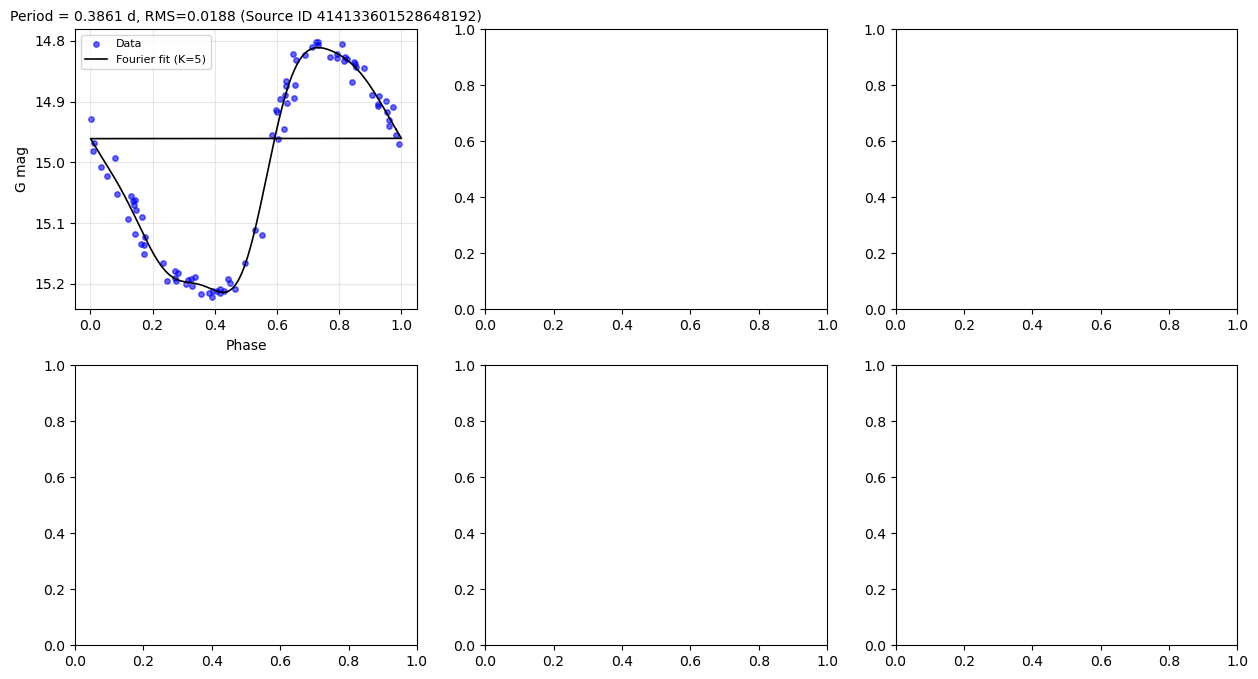

In [5]:
# --- Fetch RRc ---
df_rrc = analyzer_rrc.run_query(query_rrc, cache_file="lab01_ch2_rrc.csv")
source_ids_rrc = df_rrc["source_id"].tolist()
analyzer_rrc.fetch_datalink(source_ids_rrc)

# --- Fetch RRab ---
df_rrab = analyzer_rrab.run_query(query_rrab, cache_file="lab01_ch2_rrab.csv")
source_ids_rrab = df_rrab["source_id"].tolist()
analyzer_rrab.fetch_datalink(source_ids_rrab)

# --- Create 3x2 grid ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

# Plot RRc (top row)
for i, sid in enumerate(source_ids_rrc[:3]):
    df = analyzer_rrc.get_light_curve(sid)
    analyzer_rrc.analyze_light_curve(df, source_id=sid, ax=axes[i], show=False)

# Plot RRab (bottom row)
for i, sid in enumerate(source_ids_rrab[:3]):
    df = analyzer_rrab.get_light_curve(sid)
    analyzer_rrab.analyze_light_curve(df, source_id=sid, ax=axes[i+3], show=False)

# --- Final layout ---
fig.suptitle("RRc (top) and RRab (bottom) Light Curves with Fourier Fits", fontsize=14)
plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()


AttributeError: '_process_plot_var_args' object has no attribute 'prop_cycler'

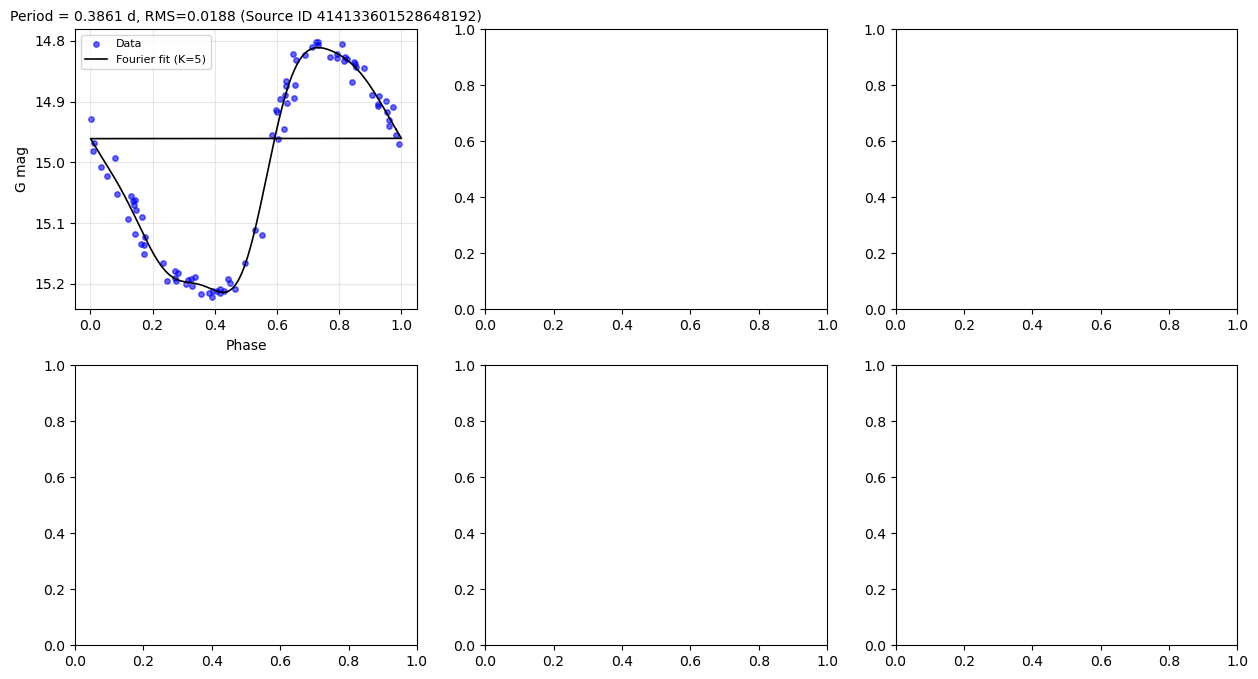

In [6]:
# --- Create 3x2 grid ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

# Plot RRc (top row)
for i, sid in enumerate(source_ids_rrc[:3]):
    df = analyzer_rrc.get_light_curve(sid)
    analyzer_rrc.analyze_light_curve(df, source_id=sid, ax=axes[i], show=False)

# Plot RRab (bottom row)
for i, sid in enumerate(source_ids_rrab[:3]):
    df = analyzer_rrab.get_light_curve(sid)
    analyzer_rrab.analyze_light_curve(df, source_id=sid, ax=axes[i+3], show=False)

# --- Final layout ---
fig.suptitle("RRc (top) and RRab (bottom) Light Curves with Fourier Fits", fontsize=14)
plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.savefig("rrab_vs_rrc_plots.jpeg")
plt.show()

In [7]:

analyzer = GaiaLightCurveAnalyzer()
query_part_12 = """
SELECT TOP 1000

gaia.source_id, 
gaia.ra,
gaia.dec,
gaia.parallax,
gaia.b,
sosrrl.pf, 
sosrrl.epoch_g,
sosrrl.int_average_g,
sosrrl.int_average_g_error

FROM gaiadr3.gaia_source AS gaia

LEFT OUTER JOIN gaiadr3.vari_rrlyrae AS sosrrl USING (source_id)

where parallax_over_error > 5

AND ABS(b) > 30

AND (1000.0/parallax) < 4000

AND sosrrl.pf IS NOT NULL

     
"""
df_part_12 = analyzer.run_query(query_part_12, cache_file="lab01_ch2_part12.csv")



Loading cached results from lab01_ch2_part12.csv


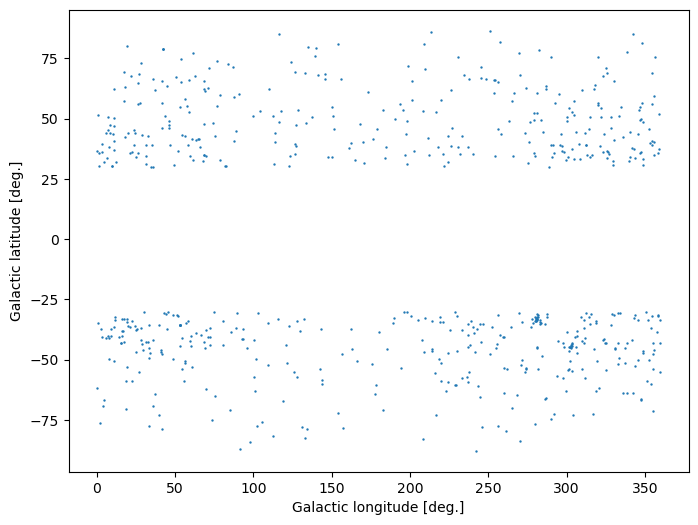

In [9]:
from astropy.coordinates import SkyCoord
import astropy.units as u

coords = SkyCoord(ra=df_part_12["ra"].values*u.degree,
                  dec=df_part_12["dec"].values*u.degree,
                  frame='icrs')

gal = coords.galactic
l = gal.l.deg
b = gal.b.deg

plt.figure(figsize=(8, 6))
plt.scatter(l, b, s=0.5, alpha=1)
plt.xlabel("Galactic longitude [deg.]")
plt.ylabel("Galactic latitude [deg.]")
# plt.title("Galactic Coordinates")
plt.savefig("galactic coord.jpeg")
plt.show()


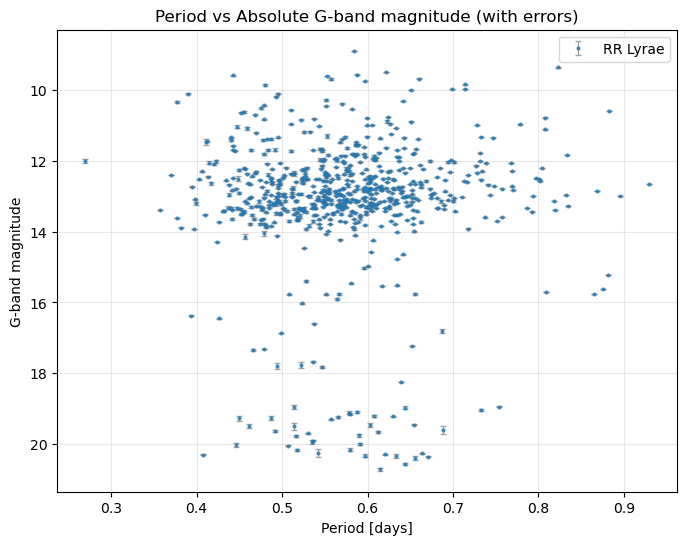

In [11]:
period = df_part_12['pf']
g_band = df_part_12['int_average_g']
g_band_error = df_part_12['int_average_g_error']

plt.figure(figsize=(8,6))

plt.errorbar(period, g_band, yerr=g_band_error,
             fmt='o', markersize=2, alpha=0.7,
             ecolor='gray', elinewidth=1, capsize=2, label="RR Lyrae")

plt.xlabel("Period [days]")
plt.ylabel("G-band magnitude")
plt.title("Period vs Absolute G-band magnitude (with errors)")
plt.gca().invert_yaxis() 
plt.grid(alpha=0.3)
plt.legend()
plt.savefig("period_gband_withoutcut.jpeg")
plt.show()


In [12]:
query_part_15 = """
SELECT TOP 1000

gaia.source_id, 
gaia.ra,
gaia.dec,
gaia.parallax,
gaia.parallax_error,
gaia.b,
gaia.ruwe,
gaia.bp_rp,
gaia.phot_bp_rp_excess_factor,
sosrrl.pf, 
sosrrl.epoch_g,
sosrrl.int_average_g,
sosrrl.int_average_g_error

FROM gaiadr3.gaia_source AS gaia

LEFT OUTER JOIN gaiadr3.vari_rrlyrae AS sosrrl USING (source_id)

where parallax_over_error > 5

AND ABS(b) > 30

AND (1000.0/parallax) < 4000

AND sosrrl.pf IS NOT NULL

     
"""
df_part_15 = analyzer.run_query(query_part_15, cache_file="lab01_ch2_part15.csv")


Loading cached results from lab01_ch2_part15.csv


Original sample: 674 stars
After quality cuts: 449 stars


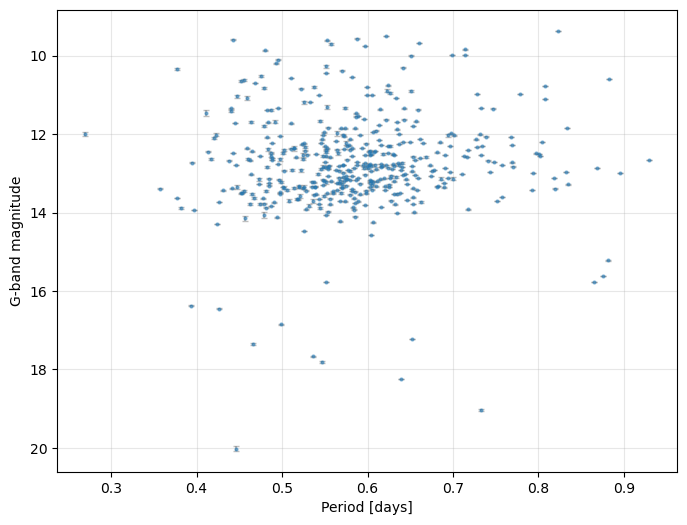

In [14]:
# Quality cuts from Lindegren et al. 2018
mask_ruwe = df_part_15["ruwe"] < 1.4

bp_rp = df_part_15["bp_rp"]
excess = df_part_15["phot_bp_rp_excess_factor"]

lower_bound = 1.0 + 0.015 * (bp_rp**2)
upper_bound = 1.3 + 0.06 * (bp_rp**2)
mask_excess = (excess > lower_bound) & (excess < upper_bound)


mask_good = mask_ruwe & mask_excess

df_clean = df_part_15[mask_good]

print(f"Original sample: {len(df_part_15)} stars")
print(f"After quality cuts: {len(df_clean)} stars")

plt.figure(figsize=(8,6))
plt.errorbar(df_clean["pf"], df_clean["int_average_g"],
             yerr=df_clean["int_average_g_error"],
             fmt='o', alpha=0.5, markersize=2,
             ecolor="gray", capsize=2)

plt.xlabel("Period [days]")
plt.ylabel("G-band magnitude")
# plt.title("Period–Luminosity relation (after quality cuts)")
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.savefig("period_mag_withcut.jpeg")
plt.show()


Acceptance fraction = 0.705 (step_size = 0.1)


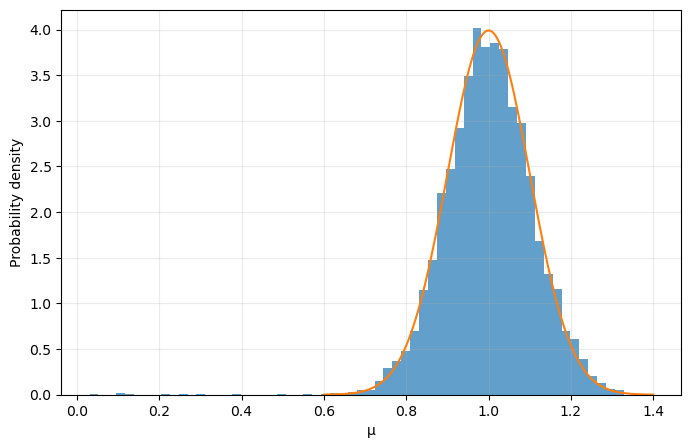

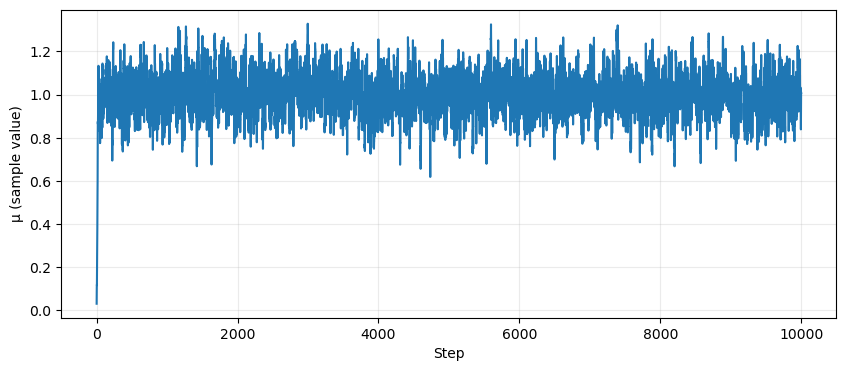

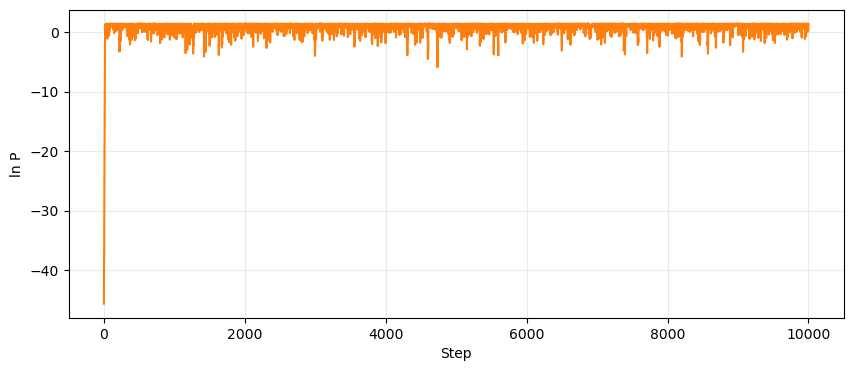

MCMC mean (after burn-in) = 1.00004, std = 0.10089
Analytic mean = 1.00000, analytic std = 0.10000


In [17]:
# Problem setup: one measurement x = 1 with error sigma = 0.1
x = 1.0
sigma = 0.1

# Target log-probability (Gaussian likelihood, flat prior -> posterior ∝ likelihood)
def lnprob(mu):
    return -0.5 * ((mu - x)**2 / sigma**2) - 0.5 * np.log(2 * np.pi * sigma**2)

# Metropolis-Hastings sampler with Gaussian proposal
def metropolis_hastings(initial, nsteps, step_size, rng):
    samples = np.zeros(nsteps)
    lnps = np.zeros(nsteps)
    current = initial
    current_lnprob = lnprob(current)
    accept_count = 0
    
    for i in range(nsteps):
        # propose
        proposal = current + rng.normal(scale=step_size)
        prop_lnprob = lnprob(proposal)
        
        # acceptance rule using log-probabilities
        lnalpha = prop_lnprob - current_lnprob
        if np.log(rng.random()) < lnalpha:
            current = proposal
            current_lnprob = prop_lnprob
            accept_count += 1
        
        samples[i] = current
        lnps[i] = current_lnprob
    
    return samples, lnps, accept_count / nsteps

# Run the sampler
rng = np.random.default_rng(42)
nsteps = 10000
initial = 0.0  # start away from the peak to show convergence
step_size = 0.10  # chosen to give acceptance fraction ~0.5 (tweakable)

samples, lnps, acc_frac = metropolis_hastings(initial, nsteps, step_size, rng)

# Print acceptance fraction
print(f"Acceptance fraction = {acc_frac:.3f} (step_size = {step_size})")

# --- Plot 1: normalized histogram of samples with analytic Gaussian overlaid ---
plt.figure(figsize=(8,5))
counts, bins, _ = plt.hist(samples, bins=60, density=True, alpha=0.7)

# analytic probability density
mu_grid = np.linspace(0.6, 1.4, 400)
pdf = (1.0 / np.sqrt(2*np.pi*sigma**2)) * np.exp(-0.5 * ((mu_grid - x)**2 / sigma**2))
plt.plot(mu_grid, pdf)
plt.xlabel('µ')
plt.ylabel('Probability density')
# plt.title('Normalized histogram of MCMC samples vs analytic likelihood')
plt.grid(alpha=0.25)
plt.savefig('histogram of mcmc.jpeg')
plt.show()

# --- Plot 2: trace of µ vs step number (qualitative convergence) ---
plt.figure(figsize=(10,4))
plt.plot(np.arange(nsteps), samples)
plt.xlabel('Step')
plt.ylabel('µ (sample value)')
# plt.title('Trace of µ vs step number')
plt.grid(alpha=0.25)
plt.savefig('trace of mu vs step number.jpeg')
plt.show()

# --- Plot 2b: trace of ln P (log-probability) vs step number ---
plt.figure(figsize=(10,4))
plt.plot(np.arange(nsteps), lnps, color="C1")
plt.xlabel('Step')
plt.ylabel('ln P')
# plt.title('Trace of log-probability vs step number')
plt.grid(alpha=0.25)
plt.savefig('trace of prob vs step number.jpeg')
plt.show()

# Diagnostics: mean/std of posterior compared to analytic
mean_mcmc = np.mean(samples[int(nsteps/4):])  # discard first quarter as burn-in
std_mcmc = np.std(samples[int(nsteps/4):])
print(f"MCMC mean (after burn-in) = {mean_mcmc:.5f}, std = {std_mcmc:.5f}")
print(f"Analytic mean = {x:.5f}, analytic std = {sigma:.5f}")


In [31]:
# Avoiding objects with zero or negative parallax
mask = (df_clean['parallax'] > 0) & np.isfinite(df_clean['parallax'])
df = df_clean[mask].copy()

# distance in parsec
df['dist_pc'] = 1000.0 / df['parallax']   # parallax in mas -> d (pc)
# absolute magnitude
df['MG'] = df['int_average_g'] - 5.0 * np.log10(df['dist_pc']) + 5.0

# error propagation: sigma_M = (5 / ln10) * (sigma_d / d)
# and sigma_d/d ≈ sigma_parallax / parallax  (since d ∝ 1/parallax)
ln10 = np.log(10.)
df['sigma_M_parallax'] = (5.0 / ln10) * (df['parallax_error'] / df['parallax'])

if 'int_average_g_error' in df.columns:
    df['sigma_M'] = np.sqrt(df['sigma_M_parallax']**2 + df['int_average_g_error']**2)
else:
    df['sigma_M'] = df['sigma_M_parallax']


period = df['pf'].values         
logP = np.log10(period)
MG = df['MG'].values
sigma_i = df['sigma_M'].values    

print(f"Using {len(df)} objects after removing non-positive parallaxes.")


Using 449 objects after removing non-positive parallaxes.


In [32]:
# --- log-posterior ---
def log_prior(theta):
    a, b, log_sigma = theta
    # priors (change hyperparams if you want)
    lp_a = -0.5 * ((a - (-2.5))**2 / 5.0**2)  - 0.5*np.log(2*np.pi*5.0**2)
    lp_b = -0.5 * ((b - 0.0)**2 / 10.0**2)    - 0.5*np.log(2*np.pi*10.0**2)
    lp_logsigma = -0.5 * ((log_sigma - (-2.0))**2 / 2.0**2) - 0.5*np.log(2*np.pi*2.0**2)
    return lp_a + lp_b + lp_logsigma

def log_likelihood(theta, logP, MG, sigma_i):
    a, b, log_sigma = theta
    sigma_scatter = np.exp(log_sigma)
    mu = a * logP + b
    var = sigma_scatter**2 + sigma_i**2
    # Gaussian log-likelihood (sum over points)
    ll = -0.5 * np.sum( (MG - mu)**2 / var + np.log(2*np.pi*var) )
    return ll

def log_posterior(theta, logP, MG, sigma_i):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    ll = log_likelihood(theta, logP, MG, sigma_i)
    return lp + ll

# --- Metropolis-Hastings 
def mh_sampler(initial, nsteps, proposal_scales, rng, logP_arr, MG_arr, sigma_i_arr):
    # initial: array-like [a, b, log_sigma]
    npar = len(initial)
    samples = np.zeros((nsteps, npar))
    lnps = np.zeros(nsteps)
    current = np.array(initial, dtype=float)
    current_lp = log_posterior(current, logP_arr, MG_arr, sigma_i_arr)
    accept = 0

    for i in range(nsteps):
        proposal = current + rng.normal(scale=proposal_scales, size=npar)
        prop_lp = log_posterior(proposal, logP_arr, MG_arr, sigma_i_arr)
        lnalpha = prop_lp - current_lp
        if np.log(rng.random()) < lnalpha:
            current = proposal
            current_lp = prop_lp
            accept += 1
        samples[i] = current
        lnps[i] = current_lp

    return samples, lnps, accept / nsteps


rng = np.random.default_rng(123)
nsteps = 50000

# initial guess
a0 = -2.0
b0 = 0.0
logsigma0 = np.log(0.05)
initial = [a0, b0, logsigma0]


proposal_scales = np.array([0.02, 0.05, 0.05])   

samples, lnps, acc_frac = mh_sampler(initial, nsteps, proposal_scales, rng, logP, MG, sigma_i)
print("MH acceptance fraction:", acc_frac)


burn = int(0.2*nsteps)
posterior_samples = samples[burn::5]   
a_samples = posterior_samples[:,0]
b_samples = posterior_samples[:,1]
sigma_samples = np.exp(posterior_samples[:,2])

print("Posterior sample sizes:", posterior_samples.shape)


MH acceptance fraction: 0.49956
Posterior sample sizes: (8000, 3)


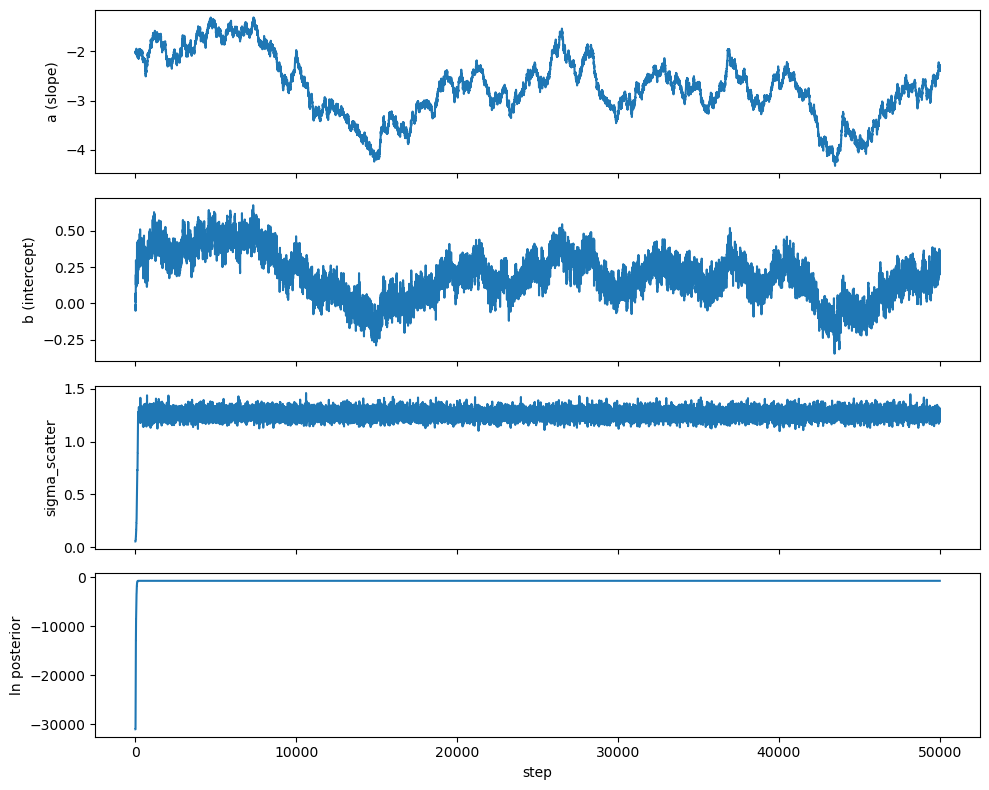

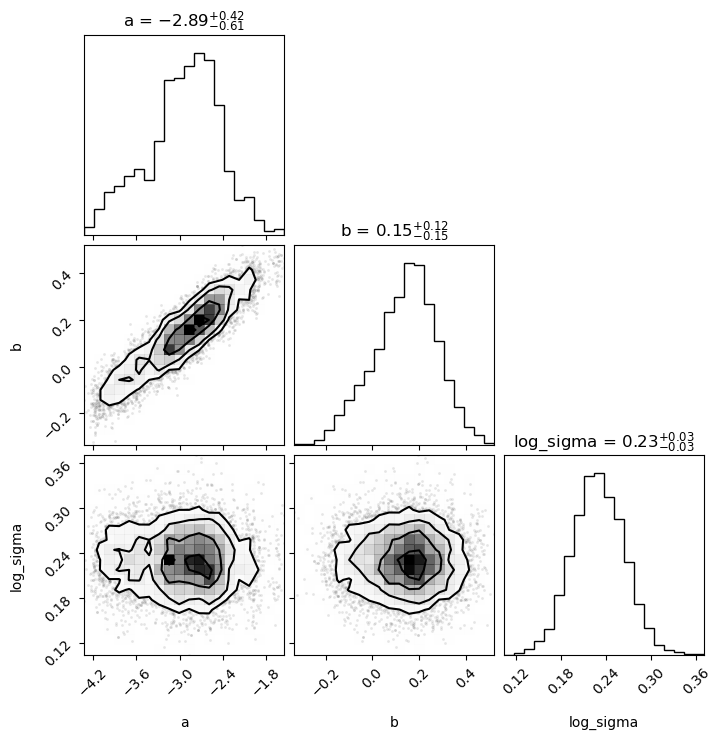

In [33]:
import corner

fig, axes = plt.subplots(4,1, figsize=(10,8), sharex=True)
axes[0].plot(samples[:,0]); axes[0].set_ylabel('a (slope)')
axes[1].plot(samples[:,1]); axes[1].set_ylabel('b (intercept)')
axes[2].plot(np.exp(samples[:,2])); axes[2].set_ylabel('sigma_scatter')
axes[3].plot(lnps); axes[3].set_ylabel('ln posterior'); axes[3].set_xlabel('step')
plt.tight_layout()
plt.savefig('convergence of sampler.jpeg')
plt.show()



corner.corner(posterior_samples, labels=['a','b','log_sigma'], truths=None, show_titles=True)
plt.savefig('corner plot of sampler.jpeg')
plt.show()

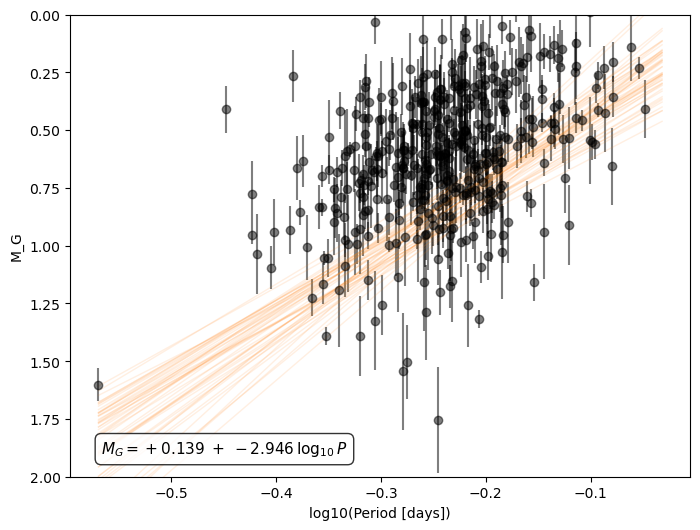

In [34]:

idx = rng.choice(len(posterior_samples), size=50, replace=False)
plt.figure(figsize=(8,6))
plt.errorbar(logP, MG, yerr=sigma_i,c='black', fmt='o', alpha=0.5, label='data')
xgrid_log = np.linspace(logP.min(), logP.max(), 200)

for i in idx:
    a_s, b_s, log_s = posterior_samples[i]
    y = a_s * xgrid_log + b_s        # y vs logP
    plt.plot(xgrid_log, y, alpha=0.12, linewidth=1, color='C1')

a_mean = a_samples.mean()
b_mean = b_samples.mean()

eq_text = fr'$M_G = {b_mean:+.3f} \;+\; {a_mean:+.3f}\,\log_{{10}}P$'
plt.text(
    0.05, 0.05,
    eq_text,
    transform=plt.gca().transAxes,
    fontsize=11,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=0.4')
)
plt.gca().invert_yaxis()
plt.xlabel('log10(Period [days])')
plt.ylabel('M_G')
plt.ylim(2,0)
# plt.title('50 posterior fits')
plt.savefig('50 posterior fits.jpeg')
plt.show()



In the above plot it shows your observed period–luminosity data along with about 50 random fits drawn from your Bayesian posterior. Each line is a plausible “best-fit” relation between period and absolute magnitude given your data and uncertainties. The bundle of lines visualizes how uncertain that relation is.Yes, the spread between posterior samples as a function of period appears consistent with the data. The bundle of sampled fits is relatively tight where the data are dense and have small measurement errors, indicating the slope and intercept are well constrained in that range. At longer (or shorter) periods, where there are fewer stars and the observed scatter is larger, the fits fan out more widely — reflecting greater uncertainty in the model’s predictions. Overall, the posterior spread qualitatively matches the level of scatter and sampling density seen in the data, as expected for a well-behaved Bayesian fit.

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, log_sigma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 2 seconds.


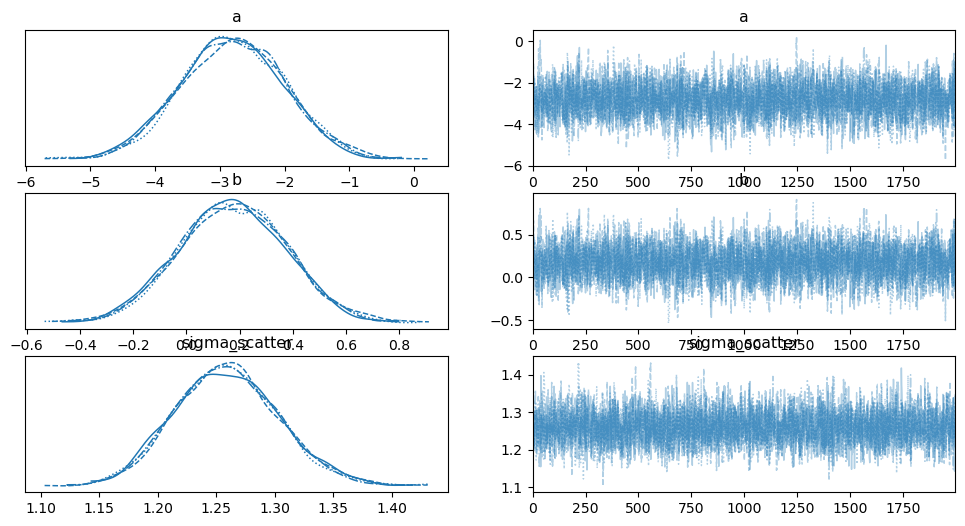

In [35]:
import pymc as pm
import arviz as az

with pm.Model() as model_potential:
    a = pm.Normal('a', mu=-2.5, sigma=5.0)
    b = pm.Normal('b', mu=0.0, sigma=10.0)
    log_sigma = pm.Normal('log_sigma', mu=-2.0, sigma=2.0)
    sigma_scatter = pm.Deterministic('sigma_scatter', pm.math.exp(log_sigma))

    mu = a * logP + b
    var = sigma_scatter**2 + sigma_i**2
    # log-likelihood
    ll = -0.5 * ( (MG - mu)**2 / var + np.log(2*np.pi*var) )
    pm.Potential('like', ll.sum())

    # sample with NUTS
    idata = pm.sample(2000, tune=2000, cores=4)

az.plot_trace(idata, var_names=['a','b','sigma_scatter'])
plt.show()


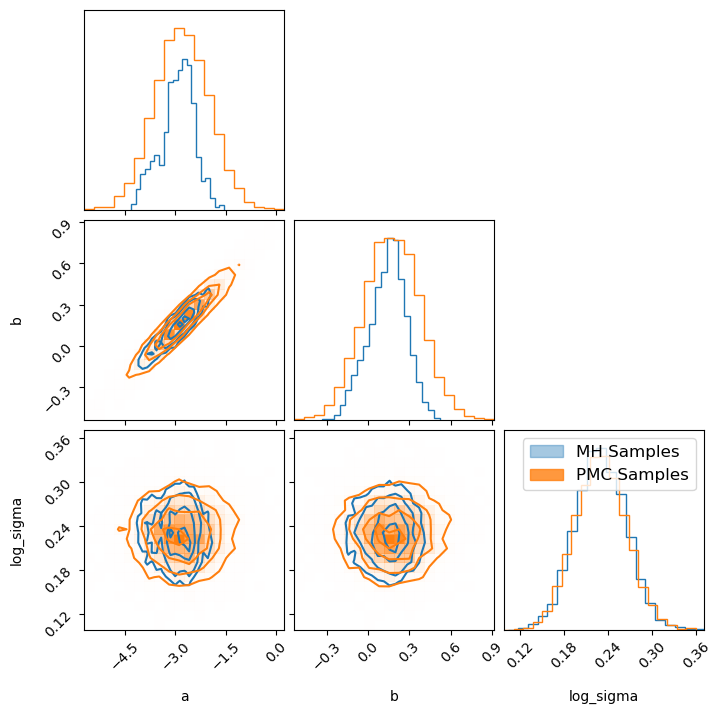

In [38]:
import matplotlib.patches as mpatches

mh_samples = np.vstack([a_samples, b_samples, np.log(sigma_samples)]).T 

posterior_pmc = idata.posterior  
a_pmc = posterior_pmc['a'].values.flatten()
b_pmc = posterior_pmc['b'].values.flatten()
logsigma_pmc = np.log(posterior_pmc['sigma_scatter'].values.flatten())
pmc_samples = np.vstack([a_pmc, b_pmc, logsigma_pmc]).T

fig = corner.corner(
    mh_samples, labels=['a','b','log_sigma'],
    color='C0', plot_datapoints=False, fill_contours=True, alpha=0.2
)


corner.corner(
    pmc_samples, labels=['a','b','log_sigma'],
    color='C1', fig=fig, plot_datapoints=False, fill_contours=False
)
blue_patch = mpatches.Patch(color='C0', alpha=0.4, label='MH Samples')
orange_patch = mpatches.Patch(color='C1', alpha=0.8, label='PMC Samples')
plt.legend(handles=[blue_patch, orange_patch], loc="upper right", fontsize=12)
plt.savefig("mh and pmc sampler corner plot.jpeg")
plt.show()





In [37]:
analyzer = GaiaLightCurveAnalyzer()

query_part_19 = """
SELECT 
g.source_id,
g.ra, g.dec,
g.b,
g.ruwe,
g.bp_rp,
g.parallax, 
g.parallax_over_error,
g.phot_bp_rp_excess_factor,
s.pf,
s.epoch_g,
s.int_average_g,
s.int_average_g_error,
aw.number_of_neighbours,
aw.allwise_oid,
awn.allwise_oid


FROM gaiadr3.gaia_source AS g

LEFT OUTER JOIN gaiadr3.vari_rrlyrae AS s USING (source_id)

LEFT JOIN gaiadr3.allwise_best_neighbour AS aw
  ON g.source_id = aw.source_id
  
LEFT JOIN gaiadr3.allwise_neighbourhood AS awn
  ON g.source_id = awn.source_id
  
where parallax_over_error > 5

AND ABS(b) > 30

AND (1000.0/parallax) < 4000

AND s.pf IS NOT NULL
     
"""

In [ ]:
df_19 = analyzer.run_query(query_part_19, cache_file="lab01_part_19.csv")

In [ ]:
print(df_19)
print(len(df_19))